In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Import Libraries

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Dataset

In [3]:
train  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test   = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (198000, 15)
Test shape: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


# Exploratory Data Analysis (EDA)
In this section, I analyze the dataset to understand its overall structure, including column types, missing values, and basic statistical properties. This step helps in identifying data quality issues and deciding the appropriate preprocessing and feature engineering techniques.

In [4]:
print('Train Dataset Info')
train.info()

Train Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [5]:
print("Test Dataset Info")
test.info()

Test Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [6]:
print('Train columns:', train.columns.tolist())
print('Test columns:', test.columns.tolist())

Train columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']
Test columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment']


## Missing Values

In [7]:
print("Missing values in train dataset")
print(train.isnull().sum())

print("\nMissing values in test dataset")
print(test.isnull().sum())

Missing values in train dataset
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Missing values in test dataset
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


## Duplicate Rows

In [8]:
print('Number of duplicate rows:', train.duplicated().sum())

Number of duplicate rows: 0


## Descriptive Statistics

In [9]:
train.describe().round(2)

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00
mean,68.45,0.28,0.05,0.12,2.61,0.67,1.91,7.96,0.79
std,27.95,1.02,0.26,0.48,5.05,2.04,25.64,14.84,0.98
min,20.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,0.00
25%,39.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00
50%,72.00,0.00,0.00,0.00,1.00,0.00,0.00,6.00,0.00
75%,72.00,0.00,0.00,0.00,3.00,1.00,4.00,10.00,2.00
max,129.00,47.00,11.00,17.00,201.00,107.00,1860.00,1833.00,3.00


## Identify Numerical and Categorical Columns

In [10]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()
print('Numerical columns:', num_cols)
print('Categorical columns:', cat_cols)

Numerical columns: ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']
Categorical columns: ['created_date', 'race', 'religion', 'gender', 'comment']


# Label Distribution

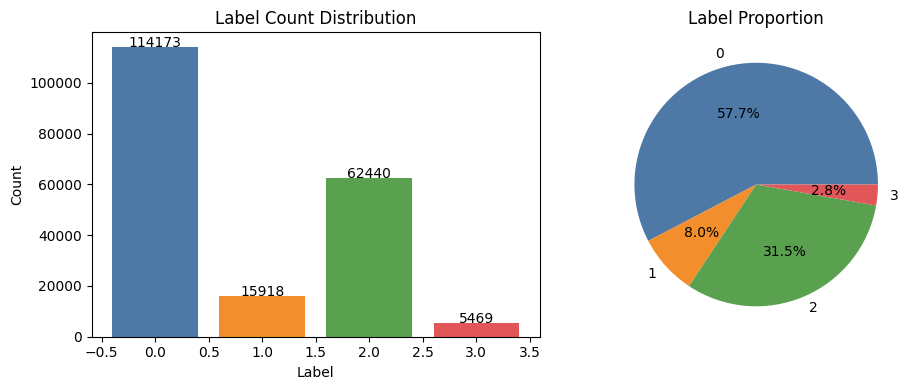

In [11]:
label_counts = train["label"].value_counts().sort_index()

colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(label_counts.index, label_counts.values, color=colors)

plt.title("Label Count Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

for i in range(len(label_counts)):
    plt.text(label_counts.index[i], label_counts.values[i],
             str(label_counts.values[i]), ha='center')

plt.subplot(1,2,2)
plt.pie(label_counts.values, labels=label_counts.index,
        autopct="%1.1f%%", colors=colors)
plt.title("Label Proportion")
plt.tight_layout()
plt.show()

The label distribution shows a strong imbalance across classes. Class 0 has the highest number of samples, forming more than half of the dataset. Class 2 is the second largest group, while class 1 has significantly fewer samples. Class 3 is the least represented class with a very small proportion.

This indicates that the data is not evenly distributed, and the minority class (class 3) has very limited representation compared to the majority classes.

# Numeric Feature Distributions

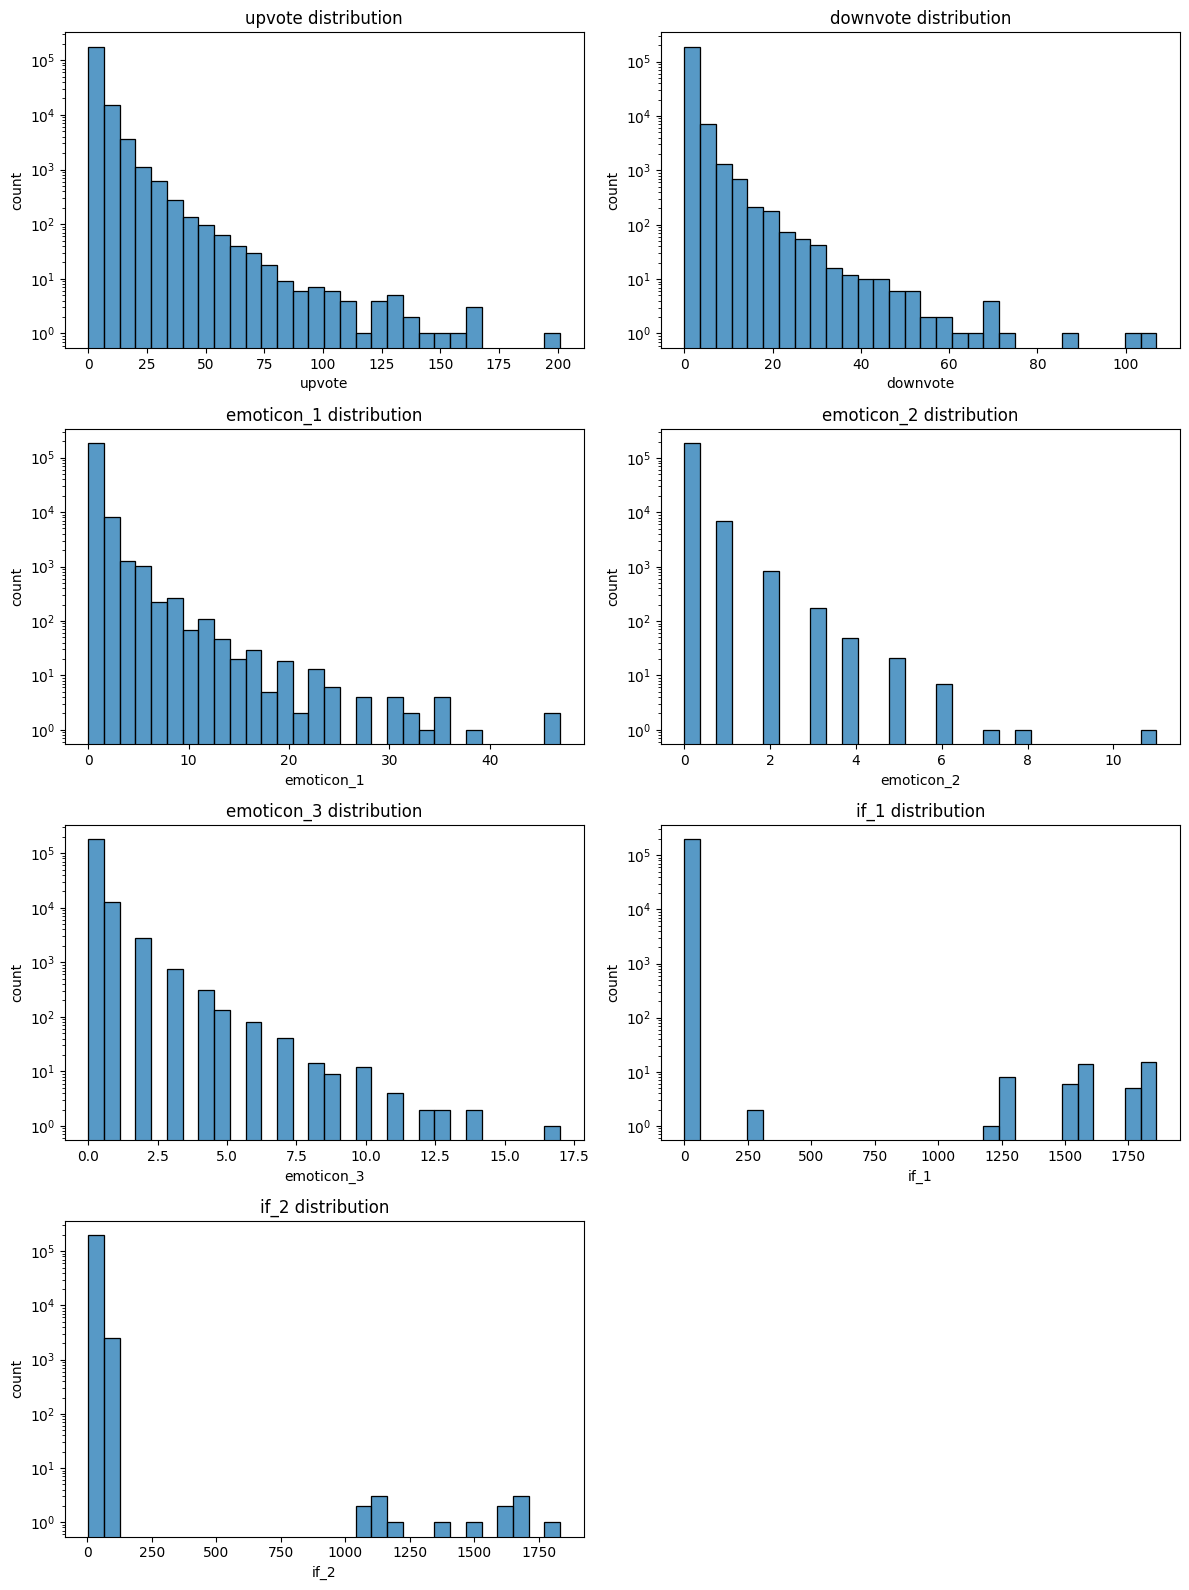

In [12]:
cols = ["upvote","downvote","emoticon_1","emoticon_2","emoticon_3","if_1","if_2"]

plt.figure(figsize=(12,16))

for i in range(len(cols)):
    plt.subplot(4,2,i+1)
    
    sns.histplot(train[cols[i]], bins=30)
    
    plt.yscale("log")   
    
    plt.title(cols[i] + " distribution")
    plt.xlabel(cols[i])
    plt.ylabel("count")

plt.tight_layout()
plt.show()

The distributions of upvote and downvote show a strong right-skewed pattern, where most values are concentrated near zero and a small number of observations have very high values. This indicates that most posts receive low engagement, while a few receive extremely high interaction.

Similarly, emoticon_1, emoticon_2, and emoticon_3 also follow a highly skewed distribution. The majority of values are close to zero, suggesting that emoticons are used infrequently, with only a few instances showing higher counts.

The features if_1 and if_2 display an even more extreme skewness, with most values clustered near zero and a few very large outliers. This indicates the presence of rare but significantly high values.

Overall, most numerical features are not normally distributed and are heavily skewed with noticeable outliers, indicating uneven spread and the presence of extreme values in the dataset.

# Correlation Heatmap

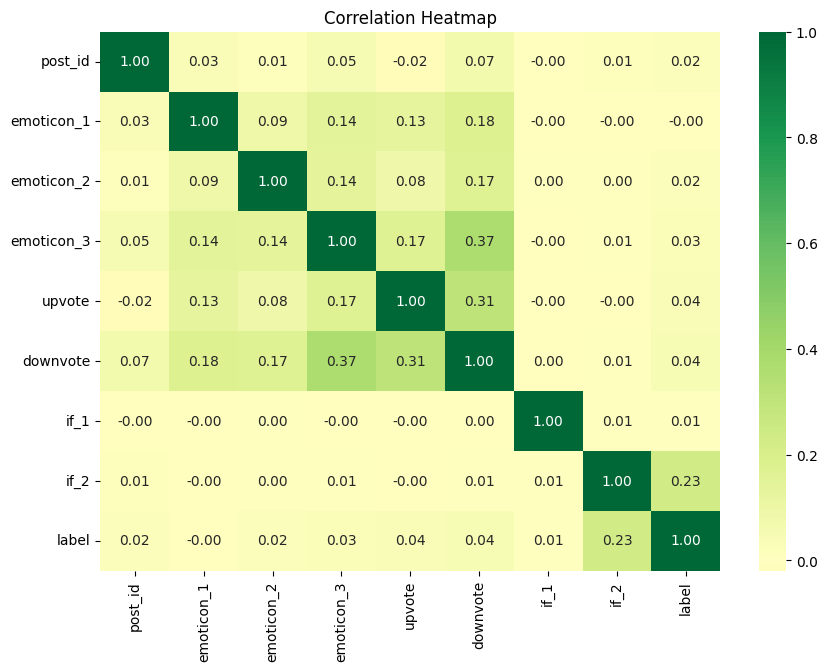

In [13]:
numeric_df = train.select_dtypes(include=["int64","float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

Most features have weak correlation with the target, with if_2 showing the highest influence. Overall, relationships are weak, indicating that predictions depend on a combination of features rather than any single feature.

# Categorical Feature Distribution

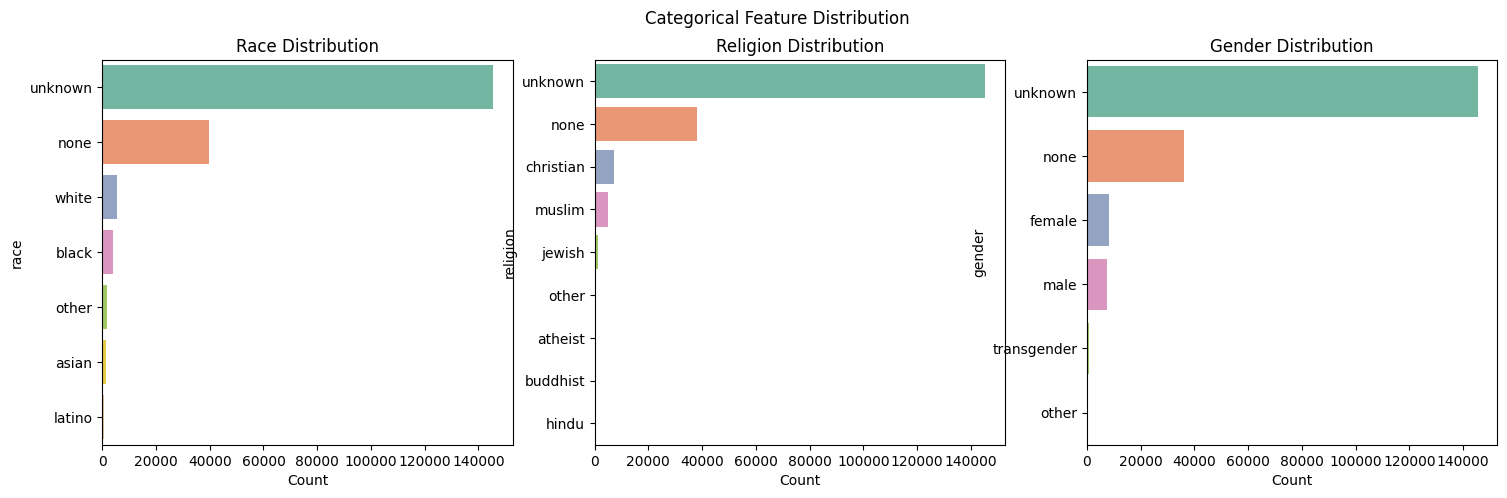

In [14]:
categorical_cols = ["race","religion","gender"]

plt.figure(figsize=(18,5))

for i,col in enumerate(categorical_cols):
    plt.subplot(1,3,i+1)
    val_counts = train[col].fillna("unknown").value_counts()

    sns.barplot(
        x=val_counts.values,
        y=val_counts.index,
        palette="Set2"
    )

    plt.title(f"{col.capitalize()} Distribution")
    plt.xlabel("Count")

plt.suptitle("Categorical Feature Distribution")
plt.show()

Most values belong to the "unknown" category, followed by "none", while all other categories have very low counts. This shows a highly skewed distribution with limited representation of specific groups.

# Categorical Feature vs Label

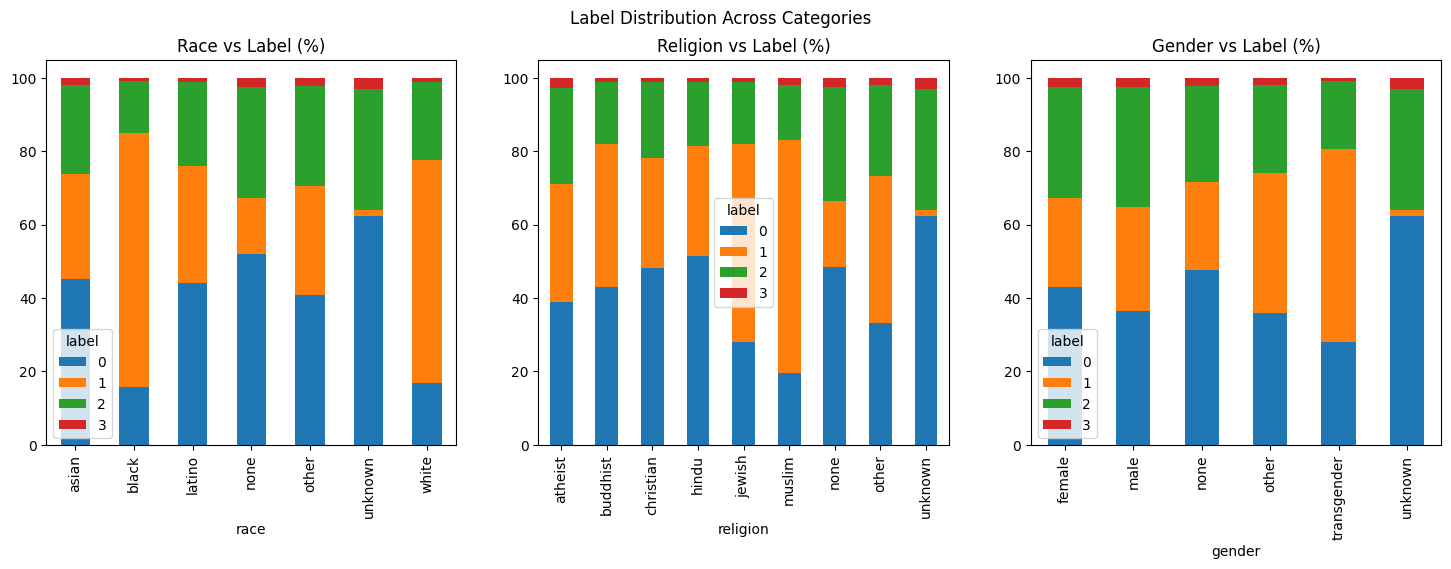

In [15]:
plt.figure(figsize=(18,5))

for i,col in enumerate(categorical_cols):
    plt.subplot(1,3,i+1)

    ct = pd.crosstab(
        train[col].fillna("unknown"),
        train["label"],
        normalize="index"
    ) * 100

    ct.plot(
        kind="bar",
        stacked=True,
        ax=plt.gca()
    )

    plt.title(f"{col.capitalize()} vs Label (%)")

plt.suptitle("Label Distribution Across Categories")
plt.show()

Label distribution remains similar across all categories, with class 0 and 2 dominating and class 3 being consistently low. No strong variation is observed across groups.

# Comment Length Analysis

In [16]:
train["comment_length"] = train["comment"].astype(str).apply(len)
train["word_count"] = train["comment"].astype(str).apply(lambda x: len(x.split()))

print(train.groupby("label")[["comment_length","word_count"]].mean())

       comment_length  word_count
label                            
0          295.897279   51.187347
1          335.709700   57.233446
2          316.893418   54.901537
3          194.171695   34.978424


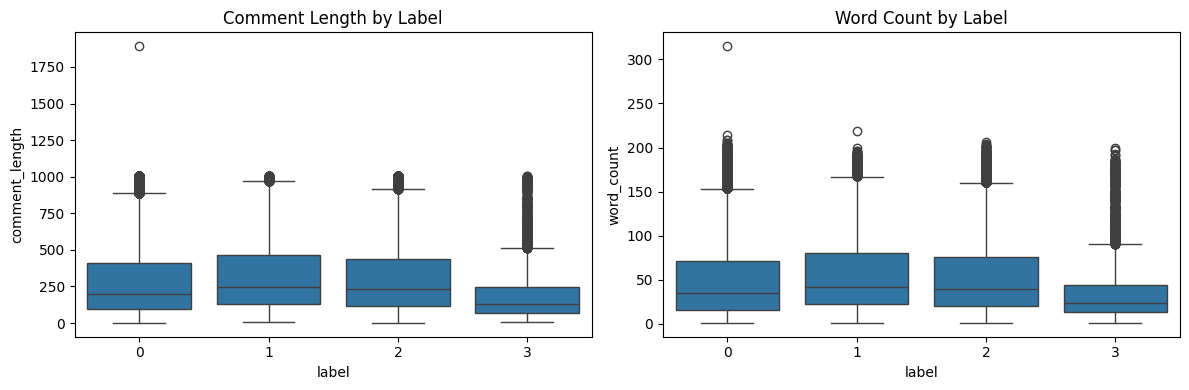

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x="label", y="comment_length", data=train)
plt.title("Comment Length by Label")

plt.subplot(1,2,2)
sns.boxplot(x="label", y="word_count", data=train)
plt.title("Word Count by Label")

plt.tight_layout()
plt.show()

Class 1 and 2 have longer comments, class 0 is moderate, and class 3 has the shortest comments. This shows clear variation in text length across labels.

## Outlier Detection using IQR Method

Feature            | Outlier Count | Outlier %
---------------------------------------------
emoticon_1         |        28,922 | 14.61%
emoticon_2         |         8,109 | 4.10%
emoticon_3         |        17,165 | 8.67%
upvote             |        17,304 | 8.74%
downvote           |        15,173 | 7.66%
if_1               |            85 | 0.04%
if_2               |         3,930 | 1.98%
comment_length     |        12,822 | 6.48%


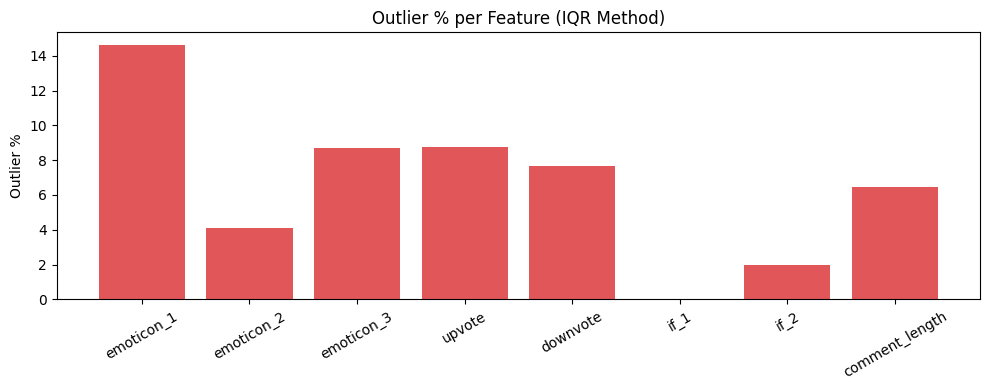

In [18]:
outlier_cols = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','comment_length']
names, pcts = [], []
print(f'{"Feature":<18} | Outlier Count | Outlier %')
print('-' * 45)
for col in outlier_cols:
    Q1  = train[col].quantile(0.25)
    Q3  = train[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = ((train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)).sum()
    names.append(col)
    pcts.append(round(n/len(train)*100, 2))
    print(f'{col:<18} | {n:>13,} | {n/len(train)*100:.2f}%')

plt.figure(figsize=(10, 4))
plt.bar(names, pcts, color='#e15759')
plt.title('Outlier % per Feature (IQR Method)')
plt.ylabel('Outlier %')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The analysis shows that several numerical features contain outliers, with emoticon_1 having the highest proportion of extreme values. Features like upvote, downvote, and emoticon_3 also show a noticeable presence of outliers, indicating that while most values are low, some instances have significantly higher values.

In contrast, features such as if_1 and if_2 have very few outliers, suggesting more consistent and stable distributions. Overall, the dataset contains a mix of stable features and features with extreme values, particularly in engagement-related variables.

## Statistical Significance - ANOVA F-Test

One-way ANOVA checks whether the mean of each numeric feature differs significantly across the 4 classes.
p < 0.05 means the feature is statistically useful for classification.

Feature            |     F-stat |    p-value | Significant?
------------------------------------------------------------
upvote             |     203.12 |     0.0000 | Yes ***
downvote           |     214.92 |     0.0000 | Yes ***
emoticon_1         |       1.85 |     0.1352 | No
emoticon_2         |      51.07 |     0.0000 | Yes ***
emoticon_3         |      68.11 |     0.0000 | Yes ***
if_1               |     330.20 |     0.0000 | Yes ***
if_2               |    4168.08 |     0.0000 | Yes ***
comment_length     |     471.06 |     0.0000 | Yes ***


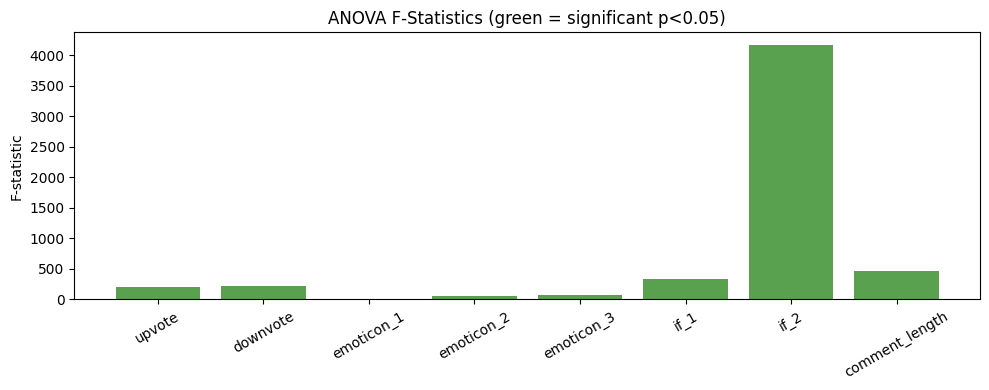

In [19]:
anova_features = ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2','comment_length']
f_stats, p_vals, names = [], [], []
print(f'{"Feature":<18} | {"F-stat":>10} | {"p-value":>10} | Significant?')
print('-' * 60)
for col in anova_features:
    groups = [train[train['label']==lbl][col].values for lbl in sorted(train['label'].unique())]
    f, p   = stats.f_oneway(*groups)
    f_stats.append(f); p_vals.append(p); names.append(col)
    print(f'{col:<18} | {f:>10.2f} | {p:>10.4f} | {"Yes ***" if p < 0.05 else "No"}')

plt.figure(figsize=(10, 4))
colors = ['#59a14f' if p < 0.05 else '#e15759' for p in p_vals]
plt.bar(names, f_stats, color=colors)
plt.title('ANOVA F-Statistics (green = significant p<0.05)')
plt.ylabel('F-statistic')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The analysis shows that most features have a statistically significant relationship with the target label, as indicated by very low p-values. Among all features, if_2 has the highest F-statistic, suggesting it is the most influential feature in distinguishing between different classes.

Features like comment_length and if_1 also show strong significance, followed by upvote, downvote, emoticon_2, and emoticon_3, indicating that they contribute meaningfully to the target variable.

However, emoticon_1 does not show statistical significance, suggesting that it has limited impact compared to other features. Overall, the results indicate that multiple features provide useful information, with some features being more influential than others.

# Data Cleaning

race, religion and gender each have ~73% missing values in both train and test - too sparse to impute reliably, so they are dropped.
Remaining nulls are filled with safe defaults.

In [20]:
train = train.drop(columns=['race','religion','gender'])
test  = test.drop(columns=['race','religion','gender'])

train['comment'] = train['comment'].fillna('')
test['comment'] = test['comment'].fillna('')
train['disability'] = train['disability'].fillna(0).astype(int)
test['disability'] = test['disability'].fillna(0).astype(int)

for col in ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

print('train shape after cleaning:', train.shape)
print('test  shape after cleaning:', test.shape)

train shape after cleaning: (198000, 14)
test  shape after cleaning: (102000, 11)


# Text Preprocessing

Raw comment text is normalised before TF-IDF vectorisation.
Punctuation-based signals (caps ratio, exclamation count, etc.) are extracted as meta-features **before** this step so no information is lost.

In [21]:
def clean_comment(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean_text'] = train['comment'].apply(clean_comment)
test['clean_text'] = test['comment'].apply(clean_comment)

print('Sample cleaned comment:')
print(train['clean_text'].iloc[0][:120])

Sample cleaned comment:
she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals


# Feature Engineering


In [22]:
# Log-transform right-skewed numeric columns to compress outlier range

log_cols = ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']
for col in log_cols:
    train['log_' + col] = np.log1p(train[col])
    test['log_'  + col] = np.log1p(test[col])

# Raw text length signals - longer comments tend to belong to specific classes

train['comm_len'] = train['comment'].str.len().fillna(0)
test['comm_len'] = test['comment'].str.len().fillna(0)
train['word_count'] = train['comment'].apply(lambda x: len(str(x).split()))
test['word_count'] = test['comment'].apply(lambda x: len(str(x).split()))
train['avg_word_len'] = train['comment'].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0)
test['avg_word_len'] = test['comment'].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0)

# Writing style ratios - aggressive or emotional text often has high caps/punctuation

train['upper_ratio'] = train['comment'].apply(lambda x: sum(c.isupper() for c in str(x)) / (len(str(x)) + 1))
test['upper_ratio'] = test['comment'].apply(lambda x: sum(c.isupper() for c in str(x)) / (len(str(x)) + 1))
train['punct_ratio'] = train['comment'].apply(lambda x: sum(c in '!?.,;:' for c in str(x)) / (len(str(x)) + 1))
test['punct_ratio'] = test['comment'].apply(lambda x: sum(c in '!?.,;:' for c in str(x)) / (len(str(x)) + 1))
train['digit_ratio'] = train['comment'].apply(lambda x: sum(c.isdigit() for c in str(x)) / (len(str(x)) + 1))
test['digit_ratio'] = test['comment'].apply(lambda x: sum(c.isdigit() for c in str(x)) / (len(str(x)) + 1))

# Intensity flag - multiple repeated punctuation marks signal strong emotion

train['is_intense'] = train['comment'].apply(lambda x: int('!!!' in str(x) or '???' in str(x)))
test['is_intense'] = test['comment'].apply(lambda x: int('!!!' in str(x) or '???' in str(x)))

# Engagement features - combined emoticon and vote interaction signals

train['emoticon_total'] = train['emoticon_1'] + train['emoticon_2'] + train['emoticon_3']
test['emoticon_total'] = test['emoticon_1']  + test['emoticon_2']  + test['emoticon_3']
train['upvote_ratio'] = train['upvote'] / (train['downvote'] + 1)
test['upvote_ratio'] = test['upvote']  / (test['downvote']  + 1)
train['upvote_x_if2'] = train['upvote'] * train['if_2']
test['upvote_x_if2'] = test['upvote']  * test['if_2']

# Hate-word count - simple lexicon that captures toxic vocabulary directly

hate_words = {'hate','kill','die','stupid','idiot','loser','ugly','trash',
              'worthless','racist','sexist','disgusting','moron','dumb','jerk'}
train['hate_count'] = train['clean_text'].apply(lambda x: sum(w in hate_words for w in x.split()))
test['hate_count'] = test['clean_text'].apply(lambda x: sum(w in hate_words for w in x.split()))

META_COLS = [
    'log_upvote','log_downvote','log_emoticon_1','log_emoticon_2',
    'log_emoticon_3','log_if_1','log_if_2','comm_len','word_count',
    'avg_word_len','upper_ratio','punct_ratio','digit_ratio',
    'is_intense','emoticon_total','upvote_ratio','upvote_x_if2',
    'hate_count','disability'
]

y = train['label']
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    train, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)


scaler       = MinMaxScaler()
scaler.fit(X_train_raw[META_COLS].fillna(0))
X_meta_train = scaler.transform(train[META_COLS].fillna(0))
X_meta_test  = scaler.transform(test[META_COLS].fillna(0))

print(f'meta features : {len(META_COLS)}')
print(f'train split   : {len(X_train_raw):,}  |  val split : {len(X_val_raw):,}')

meta features : 19
train split   : 168,300  |  val split : 29,700


# TF-IDF Vectorisation

Two TF-IDF representations are built and concatenated with the meta features:

- **Word n-gram (1–2):** captures vocabulary and short phrases  
- **Character n-gram (3–5):** captures sub-word patterns, spelling variations and morphological toxicity signals

In [23]:
word_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.97
)
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=30000,
    min_df=3,
    sublinear_tf=True
)

word_tfidf.fit(train['clean_text'])
char_tfidf.fit(train['clean_text'])

X_word_full = word_tfidf.transform(train['clean_text'])
X_char_full = char_tfidf.transform(train['clean_text'])
X_word_test = word_tfidf.transform(test['clean_text'])
X_char_test = char_tfidf.transform(test['clean_text'])

X_combined_train = hstack([X_word_full, X_char_full, csr_matrix(X_meta_train)]).tocsr()
X_combined_test = hstack([X_word_test, X_char_test, csr_matrix(X_meta_test)]).tocsr()

train_idx = X_train_raw.index
val_idx = X_val_raw.index
X_train = X_combined_train[train_idx]
X_val = X_combined_train[val_idx]

print(f'word vocab : {len(word_tfidf.vocabulary_):,}')
print(f'char vocab : {len(char_tfidf.vocabulary_):,}')
print(f'total features : {X_train.shape[1]:,}')
print(f'X_train : {X_train.shape}')
print(f'X_val : {X_val.shape}')

word vocab : 50,000
char vocab : 30,000
total features : 80,019
X_train : (168300, 80019)
X_val : (29700, 80019)


# Model Building 

# Logistic Regression

In [24]:
lr = LogisticRegression(
    C=2.0, max_iter=1000, solver='liblinear',
    class_weight='balanced', random_state=RANDOM_STATE
)
lr.fit(X_train, y_train)

lr_train_f1 = f1_score(y_train, lr.predict(X_train), average='macro')
lr_val_f1 = f1_score(y_val, lr.predict(X_val), average='macro')

print(f'Logistic Regression - train F1: {lr_train_f1:.4f}  |  val F1: {lr_val_f1:.4f}')
print(classification_report(y_val, lr.predict(X_val)))

Logistic Regression - train F1: 0.9174  |  val F1: 0.8184
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     17126
           1       0.73      0.81      0.77      2388
           2       0.87      0.91      0.89      9366
           3       0.63      0.68      0.66       820

    accuracy                           0.91     29700
   macro avg       0.80      0.83      0.82     29700
weighted avg       0.92      0.91      0.91     29700



## LinearSVC

In [25]:
svc_pipeline = Pipeline([
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=0.3, max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        cv=3
    ))
])
svc_pipeline.fit(X_train, y_train)

svc_train_f1 = f1_score(y_train, svc_pipeline.predict(X_train), average='macro')
svc_val_f1 = f1_score(y_val, svc_pipeline.predict(X_val), average='macro')

print(f'LinearSVC  - train F1: {svc_train_f1:.4f}  |  val F1: {svc_val_f1:.4f}')
print(classification_report(y_val, svc_pipeline.predict(X_val)))

LinearSVC  - train F1: 0.9207  |  val F1: 0.8096
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     17126
           1       0.79      0.74      0.77      2388
           2       0.85      0.92      0.89      9366
           3       0.78      0.52      0.63       820

    accuracy                           0.91     29700
   macro avg       0.85      0.78      0.81     29700
weighted avg       0.91      0.91      0.91     29700



## LightGBM

In [26]:
lgbm = LGBMClassifier(
    n_estimators=1200,
    num_leaves=127,
    learning_rate=0.03,
    colsample_bytree=0.7,
    subsample=0.8,
    subsample_freq=1,
    min_child_samples=20,
    class_weight='balanced',
    reg_lambda=1.0,
    reg_alpha=0.1,
    min_split_gain=0.01,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
    force_col_wise=True
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=80, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

lgbm_train_f1 = f1_score(y_train, lgbm.predict(X_train), average='macro')
lgbm_val_f1 = f1_score(y_val, lgbm.predict(X_val), average='macro')

print(f'LightGBM - train F1: {lgbm_train_f1:.4f}  |  val F1: {lgbm_val_f1:.4f}  |  iterations: {lgbm.best_iteration_}')
print(classification_report(y_val, lgbm.predict(X_val)))

[100]	valid_0's multi_logloss: 0.327601
[200]	valid_0's multi_logloss: 0.27636
[300]	valid_0's multi_logloss: 0.259107
[400]	valid_0's multi_logloss: 0.25198
[500]	valid_0's multi_logloss: 0.249722
LightGBM - train F1: 0.9706  |  val F1: 0.8354  |  iterations: 518
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.74      0.85      0.79      2388
           2       0.88      0.91      0.89      9366
           3       0.67      0.71      0.69       820

    accuracy                           0.92     29700
   macro avg       0.82      0.85      0.84     29700
weighted avg       0.92      0.92      0.92     29700



# Overfitting Check

Comparing train vs validation Macro F1 for each model.
A large gap indicates overfitting; a small gap with low val score indicates underfitting.

    Model  Train Macro F1  Val Macro F1    Gap
       LR        0.917359      0.818368 0.0990
LinearSVC        0.920707      0.809560 0.1111
 LightGBM        0.970645      0.835405 0.1352


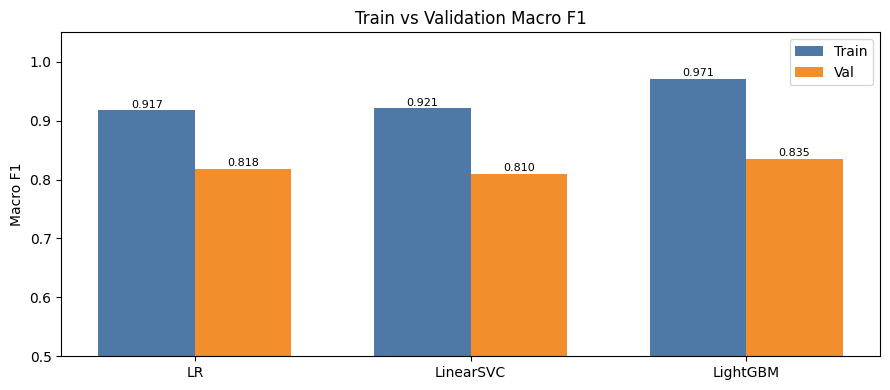

In [27]:
comparison = pd.DataFrame({
    'Model'         : ['LR', 'LinearSVC', 'LightGBM'],
    'Train Macro F1': [lr_train_f1, svc_train_f1, lgbm_train_f1],
    'Val Macro F1'  : [lr_val_f1, svc_val_f1, lgbm_val_f1],
    'Gap'           : [round(lr_train_f1 - lr_val_f1, 4),
                       round(svc_train_f1 - svc_val_f1, 4),
                       round(lgbm_train_f1 - lgbm_val_f1, 4)]
})
print(comparison.to_string(index=False))

x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, comparison['Train Macro F1'], w, label='Train', color='#4e79a7')
b2 = ax.bar(x + w/2, comparison['Val Macro F1'], w, label='Val', color='#f28e2b')
ax.set_xticks(x); ax.set_xticklabels(comparison['Model'])
ax.set_ylabel('Macro F1'); ax.set_ylim(0.5, 1.05)
ax.set_title('Train vs Validation Macro F1')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning (HPT)

## Tuning Logistic Regression

In [28]:
param_lr = {'C': [2.0, 3.0, 4.0, 5.0, 7.0, 10.0]}

search_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, solver='liblinear',
                       class_weight='balanced', random_state=RANDOM_STATE),
    param_lr, n_iter=6, cv=3,
    scoring='f1_macro', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search_lr.fit(X_train, y_train)

best_lr = search_lr.best_estimator_
lr_tuned_preds = best_lr.predict(X_val)
lr_tuned_f1 = f1_score(y_val, lr_tuned_preds, average='macro')
lr_tuned_acc = accuracy_score(y_val, lr_tuned_preds)

print(f'C selected : {search_lr.best_params_["C"]}')
print(f'CV score : {search_lr.best_score_:.4f}')
print(f'val F1 : {lr_tuned_f1:.4f}  |  val accuracy : {lr_tuned_acc:.4f}')
print(classification_report(y_val, lr_tuned_preds))

C selected : 2.0
CV score : 0.8156
val F1 : 0.8184  |  val accuracy : 0.9112
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     17126
           1       0.73      0.81      0.77      2388
           2       0.87      0.91      0.89      9366
           3       0.63      0.68      0.66       820

    accuracy                           0.91     29700
   macro avg       0.80      0.83      0.82     29700
weighted avg       0.92      0.91      0.91     29700



## Tuning LinearSVC

In [29]:
param_svc = {'clf__estimator__C': [0.1, 0.2, 0.3, 0.5, 0.7]}

search_svc = RandomizedSearchCV(
    svc_pipeline, param_svc, n_iter=5, cv=3,
    scoring='f1_macro', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search_svc.fit(X_train, y_train)

best_svc = search_svc.best_estimator_
svc_tuned_preds = best_svc.predict(X_val)
svc_tuned_f1 = f1_score(y_val, svc_tuned_preds, average='macro')
svc_tuned_acc = accuracy_score(y_val, svc_tuned_preds)

print(f'C selected : {search_svc.best_params_["clf__estimator__C"]}')
print(f'CV score : {search_svc.best_score_:.4f}')
print(f'val F1 : {svc_tuned_f1:.4f}  |  val accuracy : {svc_tuned_acc:.4f}')
print(classification_report(y_val, svc_tuned_preds))

C selected : 0.1
CV score : 0.8011
val F1 : 0.8107  |  val accuracy : 0.9128
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     17126
           1       0.79      0.75      0.77      2388
           2       0.85      0.93      0.89      9366
           3       0.78      0.52      0.63       820

    accuracy                           0.91     29700
   macro avg       0.85      0.79      0.81     29700
weighted avg       0.91      0.91      0.91     29700



# Model Comparison

   Model  Val Macro F1  Val Accuracy
LightGBM      0.835405      0.919428
      LR      0.818368      0.911212
     SVC      0.810670      0.912795


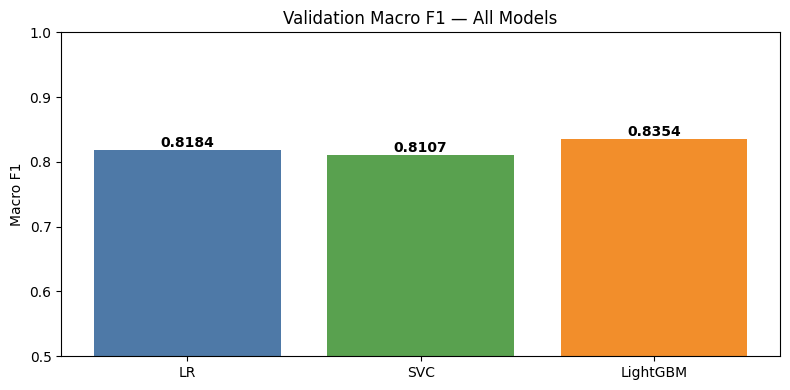

In [30]:
lgbm_val_preds = lgbm.predict(X_val)
lgbm_val_f1 = f1_score(y_val, lgbm_val_preds, average='macro')
lgbm_val_acc = accuracy_score(y_val, lgbm_val_preds)

results = pd.DataFrame({
    'Model' : ['LR', 'SVC', 'LightGBM'],
    'Val Macro F1' : [lr_tuned_f1, svc_tuned_f1, lgbm_val_f1],
    'Val Accuracy' : [lr_tuned_acc, svc_tuned_acc, lgbm_val_acc]
})
print(results.sort_values('Val Macro F1', ascending=False).to_string(index=False))

plt.figure(figsize=(8, 4))
bars = plt.bar(results['Model'], results['Val Macro F1'],
               color=['#4e79a7','#59a14f','#f28e2b'])
plt.title('Validation Macro F1 — All Models')
plt.ylabel('Macro F1')
plt.ylim(0.5, 1.0)
for bar, v in zip(bars, results['Val Macro F1']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Confusion Matrix and Per-Class Analysis

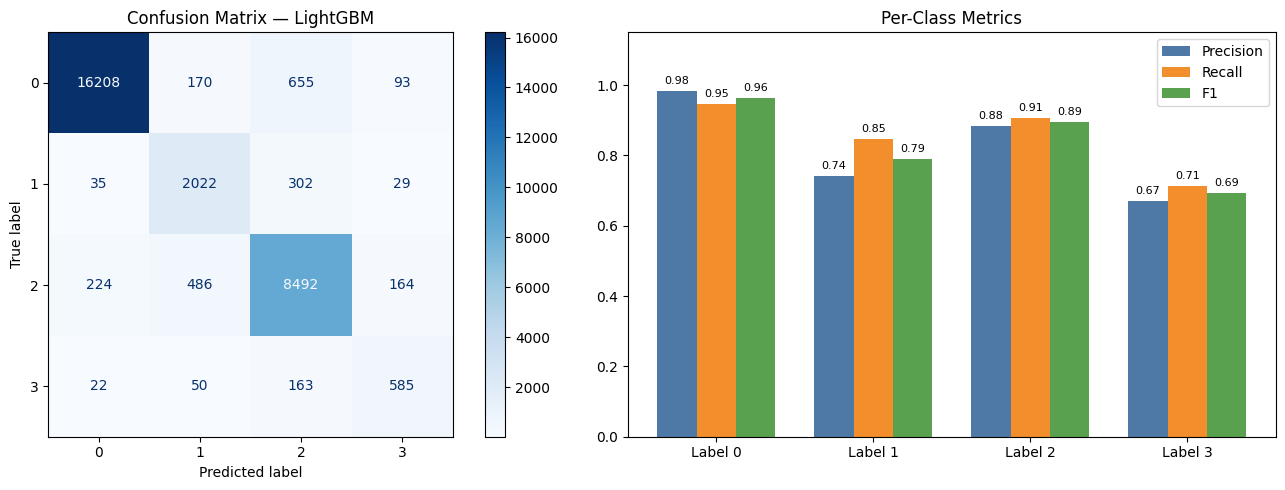

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.74      0.85      0.79      2388
           2       0.88      0.91      0.89      9366
           3       0.67      0.71      0.69       820

    accuracy                           0.92     29700
   macro avg       0.82      0.85      0.84     29700
weighted avg       0.92      0.92      0.92     29700



In [31]:
top_f1 = max(lr_tuned_f1, svc_tuned_f1, lgbm_val_f1)
if top_f1 == lgbm_val_f1:
    top_preds, top_name = lgbm_val_preds, 'LightGBM'
elif top_f1 == lr_tuned_f1:
    top_preds, top_name = lr_tuned_preds, 'LR'
else:
    top_preds, top_name = svc_tuned_preds, 'SVC'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, top_preds),
    display_labels=[0, 1, 2, 3]
).plot(cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {top_name}')

prec, rec, f1c, _ = precision_recall_fscore_support(y_val, top_preds, average=None)
labels = ['Label 0','Label 1','Label 2','Label 3']
x, w = np.arange(4), 0.25
axes[1].bar(x-w, prec, w, label='Precision', color='#4e79a7')
axes[1].bar(x, rec, w, label='Recall', color='#f28e2b')
axes[1].bar(x+w, f1c, w, label='F1', color='#59a14f')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Per-Class Metrics')
axes[1].legend()
for i, (p, r, f) in enumerate(zip(prec, rec, f1c)):
    axes[1].text(i-w, p+0.02, f'{p:.2f}', ha='center', fontsize=8)
    axes[1].text(i, r+0.02, f'{r:.2f}', ha='center', fontsize=8)
    axes[1].text(i+w, f+0.02, f'{f:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print(classification_report(y_val, top_preds))

# Final Ensemble 

In [32]:
lr_val_proba = best_lr.predict_proba(X_val)
svc_val_proba = best_svc.predict_proba(X_val)
lgbm_val_proba = lgbm.predict_proba(X_val)

best_f1_blend = 0.0
best_wl, best_ws, best_wg = 0.20, 0.15, 0.65

for wg in np.arange(0.35, 0.75, 0.05):
    for wl in np.arange(0.10, 0.50, 0.05):
        ws = round(1.0 - wl - wg, 4)
        if ws < 0.05: continue
        blend = wl * lr_val_proba + ws * svc_val_proba + wg * lgbm_val_proba
        f1    = f1_score(y_val, np.argmax(blend, axis=1), average='macro')
        if f1 > best_f1_blend:
            best_f1_blend = f1
            best_wl, best_ws, best_wg = wl, ws, wg

base_blend = best_wl * lr_val_proba + best_ws * svc_val_proba + best_wg * lgbm_val_proba
print(f'weights — LR: {best_wl:.2f}  SVC: {best_ws:.2f}  LGBM: {best_wg:.2f}')
print(f'blend val F1 : {best_f1_blend:.4f}')
print(classification_report(y_val, np.argmax(base_blend, axis=1)))

best_alpha, best_alpha_f1 = 1.0, best_f1_blend
for alpha in np.arange(1.00, 1.80, 0.02):
    boosted = base_blend.copy()
    boosted[:, 3] *= alpha
    boosted = boosted / boosted.sum(axis=1, keepdims=True)
    f1 = f1_score(y_val, np.argmax(boosted, axis=1), average='macro')
    if f1 > best_alpha_f1:
        best_alpha_f1 = f1
        best_alpha = alpha

final_blend = base_blend.copy()
final_blend[:, 3] *= best_alpha
final_blend = final_blend / final_blend.sum(axis=1, keepdims=True)
ensemble_val_preds = np.argmax(final_blend, axis=1)
ensemble_f1 = f1_score(y_val, ensemble_val_preds, average='macro')
ensemble_acc = accuracy_score(y_val, ensemble_val_preds)

print(f'label-3 alpha : {best_alpha:.2f}')
print(f'ensemble val F1: {ensemble_f1:.4f}')
print(f'ensemble val acc: {ensemble_acc:.4f}')
print()
print(classification_report(y_val, ensemble_val_preds))

weights — LR: 0.40  SVC: 0.05  LGBM: 0.55
blend val F1 : 0.8406
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.75      0.84      0.79      2388
           2       0.88      0.91      0.90      9366
           3       0.70      0.72      0.71       820

    accuracy                           0.92     29700
   macro avg       0.83      0.85      0.84     29700
weighted avg       0.92      0.92      0.92     29700

label-3 alpha : 1.08
ensemble val F1: 0.8425
ensemble val acc: 0.9214

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.75      0.84      0.80      2388
           2       0.88      0.91      0.90      9366
           3       0.69      0.74      0.71       820

    accuracy                           0.92     29700
   macro avg       0.83      0.86      0.84     29700
weighted avg       0.93      0.92      0.92     29

# Confusion Matrix - Final Ensemble

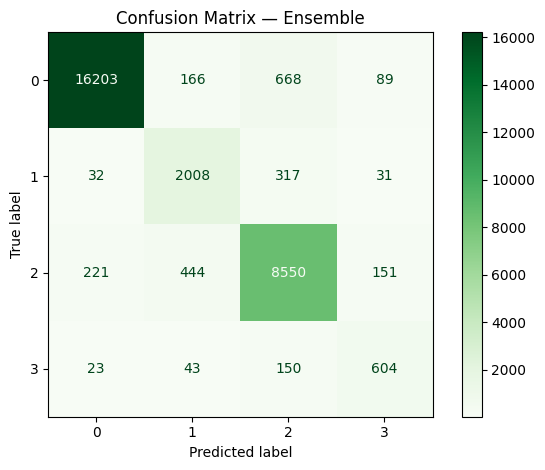


Model scores summary
---------------------------------------------
  Ensemble     : 0.8425  <--
  Blend        : 0.8406
  LightGBM     : 0.8354
  LR           : 0.8184
  SVC          : 0.8107


In [33]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, ensemble_val_preds),
    display_labels=[0, 1, 2, 3]
).plot(cmap='Greens')
plt.title('Confusion Matrix — Ensemble')
plt.tight_layout()
plt.show()

print()
print('Model scores summary')
print('-' * 45)
all_scores = {
    'LR' : lr_tuned_f1,
    'SVC' : svc_tuned_f1,
    'LightGBM' : lgbm_val_f1,
    'Blend' : best_f1_blend,
    'Ensemble' : ensemble_f1,
}
for name, score in sorted(all_scores.items(), key=lambda x: x[1], reverse=True):
    tag = '  <--' if name == 'Ensemble' else ''
    print(f'  {name:<12} : {score:.4f}{tag}')

# Final Submission

In [34]:
lr_full = LogisticRegression(
    C=search_lr.best_params_['C'], max_iter=1000, solver='liblinear',
    class_weight='balanced', random_state=RANDOM_STATE
)
lr_full.fit(X_combined_train, y)

svc_full = Pipeline([
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=search_svc.best_params_['clf__estimator__C'],
                  max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        cv=3
    ))
])
svc_full.fit(X_combined_train, y)

lgbm_full = lgbm

print(f'LR — C = {search_lr.best_params_["C"]}')
print(f'SVC — C = {search_svc.best_params_["clf__estimator__C"]}')
print(f'LGBM — iterations used: {lgbm.best_iteration_}')
print()

lr_test = lr_full.predict_proba(X_combined_test)
svc_test = svc_full.predict_proba(X_combined_test)
lgbm_test = lgbm_full.predict_proba(X_combined_test)

test_blend = best_wl * lr_test + best_ws * svc_test + best_wg * lgbm_test
test_blend[:, 3] *= best_alpha
test_blend = test_blend / test_blend.sum(axis=1, keepdims=True)
test_preds = np.argmax(test_blend, axis=1)

print('prediction distribution:')
print(pd.Series(test_preds).value_counts().sort_index().to_string())

LR — C = 2.0
SVC — C = 0.1
LGBM — iterations used: 518

prediction distribution:
0    56568
1     9014
2    33516
3     2902


In [35]:
submission = sample.copy()
submission['label'] = test_preds
submission.to_csv('submission.csv', index=False)

print(f'submission.csv saved — {len(submission):,} rows')
print(submission.head())

submission.csv saved — 102,000 rows
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
